In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Crop.csv")

# 1. Dataset shape
print("Dataset Shape:", df.shape)

# 2. First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# 3. Data types
print("\nData Types:")
print(df.dtypes)

# 4. Dataset information
print("\nDataset Info:")
df.info()

# 5. Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# 6. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (19689, 13)

First 5 Rows:


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779



Data Types:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755186,2.410331e+07,4.884835e+04,79.954011,23.831279,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.909592,9.494600e+07,2.132874e+05,878.306194,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000



Missing Values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


In [7]:
# Step 2: Core KPIs Calculation
total_production = df['Production'].sum()
avg_yield = df['Yield'].mean()
total_area = df['Area'].sum()
avg_rainfall = df['Annual_Rainfall'].mean()
avg_fertilizer = df['Fertilizer'].mean()

print("=== AGRICULTURAL BUSINESS INTELLIGENCE KPIs ===")
print(f"Total Crop Production (All Regions/Years): {total_production:,.0f} units")
print(f"Average Crop Yield: {avg_yield:.2f}")
print(f"Total Cultivated Area: {total_area:,.0f} hectares")
print(f"Average Annual Rainfall: {avg_rainfall:.2f} mm")
print(f"Average Fertilizer Usage: {avg_fertilizer:,.2f} kg/ha")

=== AGRICULTURAL BUSINESS INTELLIGENCE KPIs ===
Total Crop Production (All Regions/Years): 323,607,247,726 units
Average Crop Yield: 79.95
Total Cultivated Area: 3,542,574,243 hectares
Average Annual Rainfall: 1437.76 mm
Average Fertilizer Usage: 24,103,312.45 kg/ha


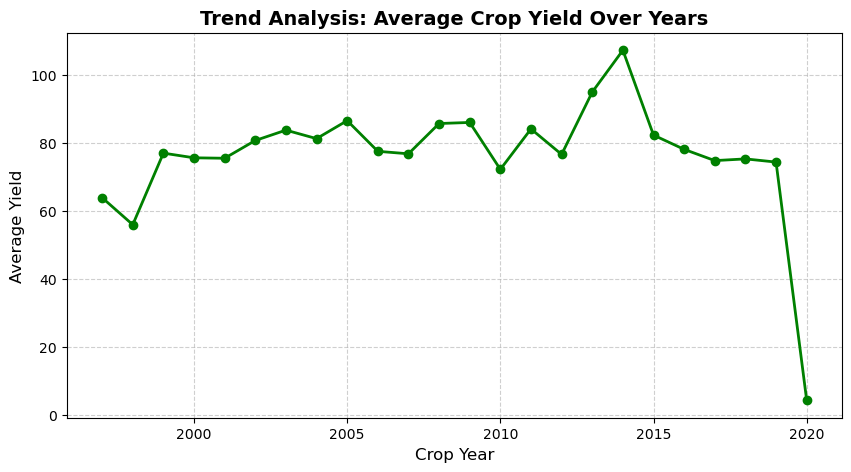

In [8]:
# Step 3: Trend Analysis (Average Yield Over Years)
import matplotlib.pyplot as plt

# Group by year and calculate average yield
yearly_trend = df.groupby('Crop_Year')['Yield'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_trend['Crop_Year'], yearly_trend['Yield'], marker='o', color='green', linewidth=2)
plt.title('Trend Analysis: Average Crop Yield Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Crop Year', fontsize=12)
plt.ylabel('Average Yield', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

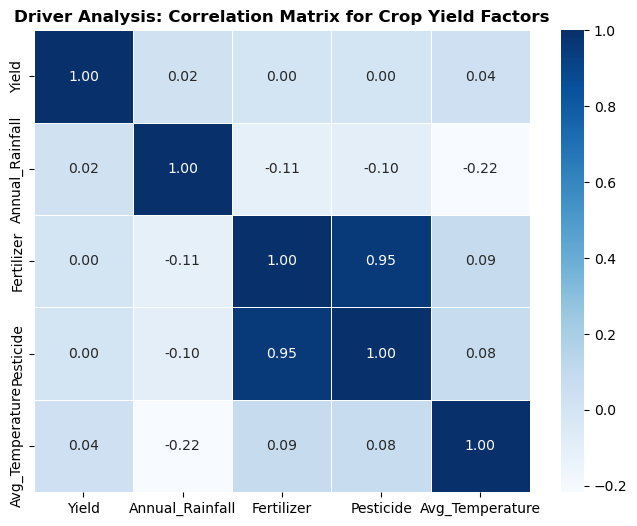

--- DRIVER INSIGHTS ---
This heatmap shows how environmental factors (Rainfall, Temperature) and farming inputs (Fertilizer, Pesticide) relate to Crop Yield.


In [9]:
# Step 4: Driver Correlation Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select key numerical variables affecting crop yield
numeric_cols = ['Yield', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature']
correlation_matrix = df[numeric_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Driver Analysis: Correlation Matrix for Crop Yield Factors', fontsize=12, fontweight='bold')
plt.show()

print("--- DRIVER INSIGHTS ---")
print("This heatmap shows how environmental factors (Rainfall, Temperature) and farming inputs (Fertilizer, Pesticide) relate to Crop Yield.")